In [28]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from pandas_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import OneHotEncoder

First READ The dataset using panda

In [4]:
dataset = pd.read_csv('../data/heart_disease_uci.csv')

HOW BIG IS THE DATA

In [5]:
dataset.shape

(920, 16)

TAKE RANDOM 10 data from the dataset to set how the data looks like

In [6]:
dataset.sample(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
871,872,71,Male,VA Long Beach,asymptomatic,130.0,221.0,False,st-t abnormality,115.0,True,0.0,NaN,NaN,NaN,3
608,609,41,Male,Switzerland,asymptomatic,125.0,0.0,NaN,normal,176.0,False,1.6,upsloping,NaN,NaN,2
438,439,53,Male,Hungary,atypical angina,140.0,320.0,False,normal,162.0,False,0.0,NaN,NaN,NaN,0
516,517,50,Male,Hungary,asymptomatic,145.0,264.0,False,normal,150.0,False,0.0,NaN,NaN,NaN,1
248,249,52,Male,Cleveland,asymptomatic,125.0,212.0,False,normal,168.0,False,1.0,upsloping,2.0,reversable defect,3
484,485,59,Male,Hungary,non-anginal,180.0,213.0,False,normal,100.0,False,0.0,NaN,NaN,NaN,0
353,354,41,Male,Hungary,atypical angina,125.0,269.0,False,normal,144.0,False,0.0,NaN,NaN,NaN,0
245,246,67,Male,Cleveland,asymptomatic,120.0,237.0,False,normal,71.0,False,1.0,flat,0.0,normal,2
93,94,44,Female,Cleveland,non-anginal,108.0,141.0,False,normal,175.0,False,0.6,flat,0.0,normal,0
836,837,55,Male,VA Long Beach,asymptomatic,116.0,186.0,True,st-t abnormality,102.0,False,0.0,NaN,NaN,NaN,2


Are there any missing values in my dataset? If so how many?

In [7]:
# Create a DataFrame combining info
null_info = pd.DataFrame({
    'Data Type': dataset.dtypes,
    'Missing (%)': dataset.isnull().mean() * 100
})

# Display neatly
null_info


,Data Type,Missing (%)
id,int64,0.000000
age,int64,0.000000
sex,object,0.000000
dataset,object,0.000000
cp,object,0.000000
trestbps,float64,6.413043
chol,float64,3.260870
fbs,object,9.782609
restecg,object,0.217391
thalch,float64,5.978261


Now we will remove the rows whose any feature value is null and the percentage of null feature value is less than 5%


In [8]:
print("Original Dataset shape", dataset.shape)
#First extract the cols which have null values less than 5%
cols = [var for var in dataset.columns if dataset[var].isnull().mean()*100 <5 and dataset[var].isnull().mean()>0]
print(cols)


Original Dataset shape (920, 16)
['chol', 'restecg']


Removing the rows which have null values with numerical variables

In [9]:
# Remove rows with null 'chol'
new_dataset = dataset.dropna(subset=['chol'])
remained_dataset_size = len(new_dataset) / len(dataset) * 100
print(f"Remained dataset size after removing rows with null values in selected columns: {remained_dataset_size:.2f}%")
print("Dataset shape after removing null values:", new_dataset.shape)

Remained dataset size after removing rows with null values in selected columns: 96.74%
Dataset shape after removing null values: (890, 16)


Now I will see the distrubution of original dataset and new_dataset.
If the distribution is same then we can confirm that we can remove the rows

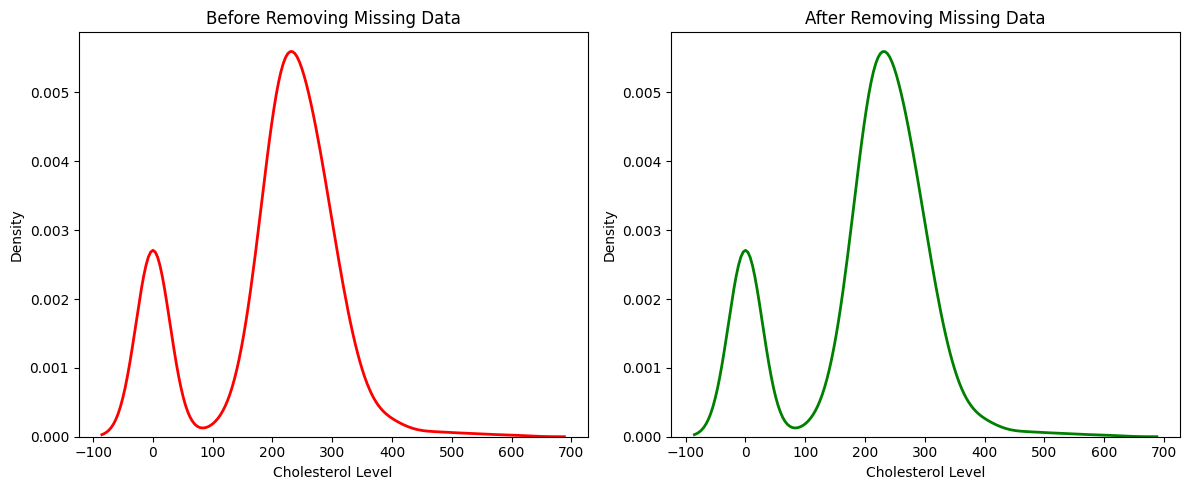

In [10]:

# Before and after
before = dataset['chol']
after = new_dataset['chol']


# Create 1 row, 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before removal
sb.kdeplot(before, color='red', lw=2, ax=axes[0])
axes[0].set_title('Before Removing Missing Data')
axes[0].set_xlabel('Cholesterol Level')
axes[0].set_ylabel('Density')

# After removal
sb.kdeplot(after, color='green', lw=2, ax=axes[1])
axes[1].set_title('After Removing Missing Data')
axes[1].set_xlabel('Cholesterol Level')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

dataset = new_dataset


Removing the rows which have null values with categorical variables

In [11]:

new_dataset = dataset.dropna(subset=['restecg'])

temp = pd.concat([
  #Percentage of each category in 'restecg' before removal
  dataset['restecg'].value_counts()/len(dataset),
  
  #Percentage of each category in 'restecg' after removal
  new_dataset['restecg'].value_counts()/len(new_dataset),
], axis=1)


#Add column names
temp.columns = ['Before Removal', 'After Removal']
temp
#Assign the changes back to dataset
dataset = new_dataset
dataset.shape


(888, 16)

After this operation, check how many null values remains

In [12]:
# Create a DataFrame combining info
null_info = pd.DataFrame({
    'Data Type': dataset.dtypes,
    'Missing (%)': dataset.isnull().mean() * 100
})

# Display neatly
null_info

,Data Type,Missing (%)
id,int64,0.000000
age,int64,0.000000
sex,object,0.000000
dataset,object,0.000000
cp,object,0.000000
trestbps,float64,6.306306
chol,float64,0.000000
fbs,object,10.022523
restecg,object,0.000000
thalch,float64,5.855856


Drop the id,dataset,ca and thal feature as they have no significance or have very much missing values

In [13]:
print("Original dataset columns:", dataset.columns.tolist())

#define the column that should be dropped
cols_to_drop = ['id','dataset','ca','thal']

# Check which columns actually exist in the dataset
existing_columns_to_drop = [col for col in cols_to_drop if col in dataset.columns]
print(f"\nColumns to be dropped: {existing_columns_to_drop}")

#now drop the columns
cleaned_dataset = dataset.drop(columns=existing_columns_to_drop)
print("Cleaned dataset shape:", cleaned_dataset.shape)
print("Cleaned dataset columns:", cleaned_dataset.columns.tolist())

#Now save the cleaned dataset to a new CSV file so that we can continue our analysis later without repeating the cleaning steps
cleaned_dataset.to_csv('../data/heart_disease_uci_cleaned.csv', index=False)



Original dataset columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Columns to be dropped: ['id', 'dataset', 'ca', 'thal']
Cleaned dataset shape: (888, 12)
Cleaned dataset columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'num']


In [14]:
dataset = pd.read_csv('../data/heart_disease_uci_cleaned.csv')

# Create a DataFrame combining info
null_info = pd.DataFrame({
    'Data Type': dataset.dtypes,
    'Missing (%)': dataset.isnull().mean() * 100
})

# Display neatly
null_info

,Data Type,Missing (%)
age,int64,0.000000
sex,object,0.000000
cp,object,0.000000
trestbps,float64,6.306306
chol,float64,0.000000
fbs,object,10.022523
restecg,object,0.000000
thalch,float64,5.855856
exang,object,5.855856
oldpeak,float64,6.644144


Now I want to do the imputation on the numerical data and categorical data. For this I need to split the dataset into train and test dataset first

In [16]:
#Separate the features and target
target_column = 'num'

X = dataset.drop(columns=[target_column])
y = dataset[target_column]


#Split the dataset into train and test sets
X_train,X_test,y_train,y_test = train_test_split(
  X,y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

# Now I indentify the numerical and categorical features
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
target_column = 'num'


Now I will apply mean imputation on the numerical features

Numerical features with missing values: ['trestbps', 'thalch', 'oldpeak']


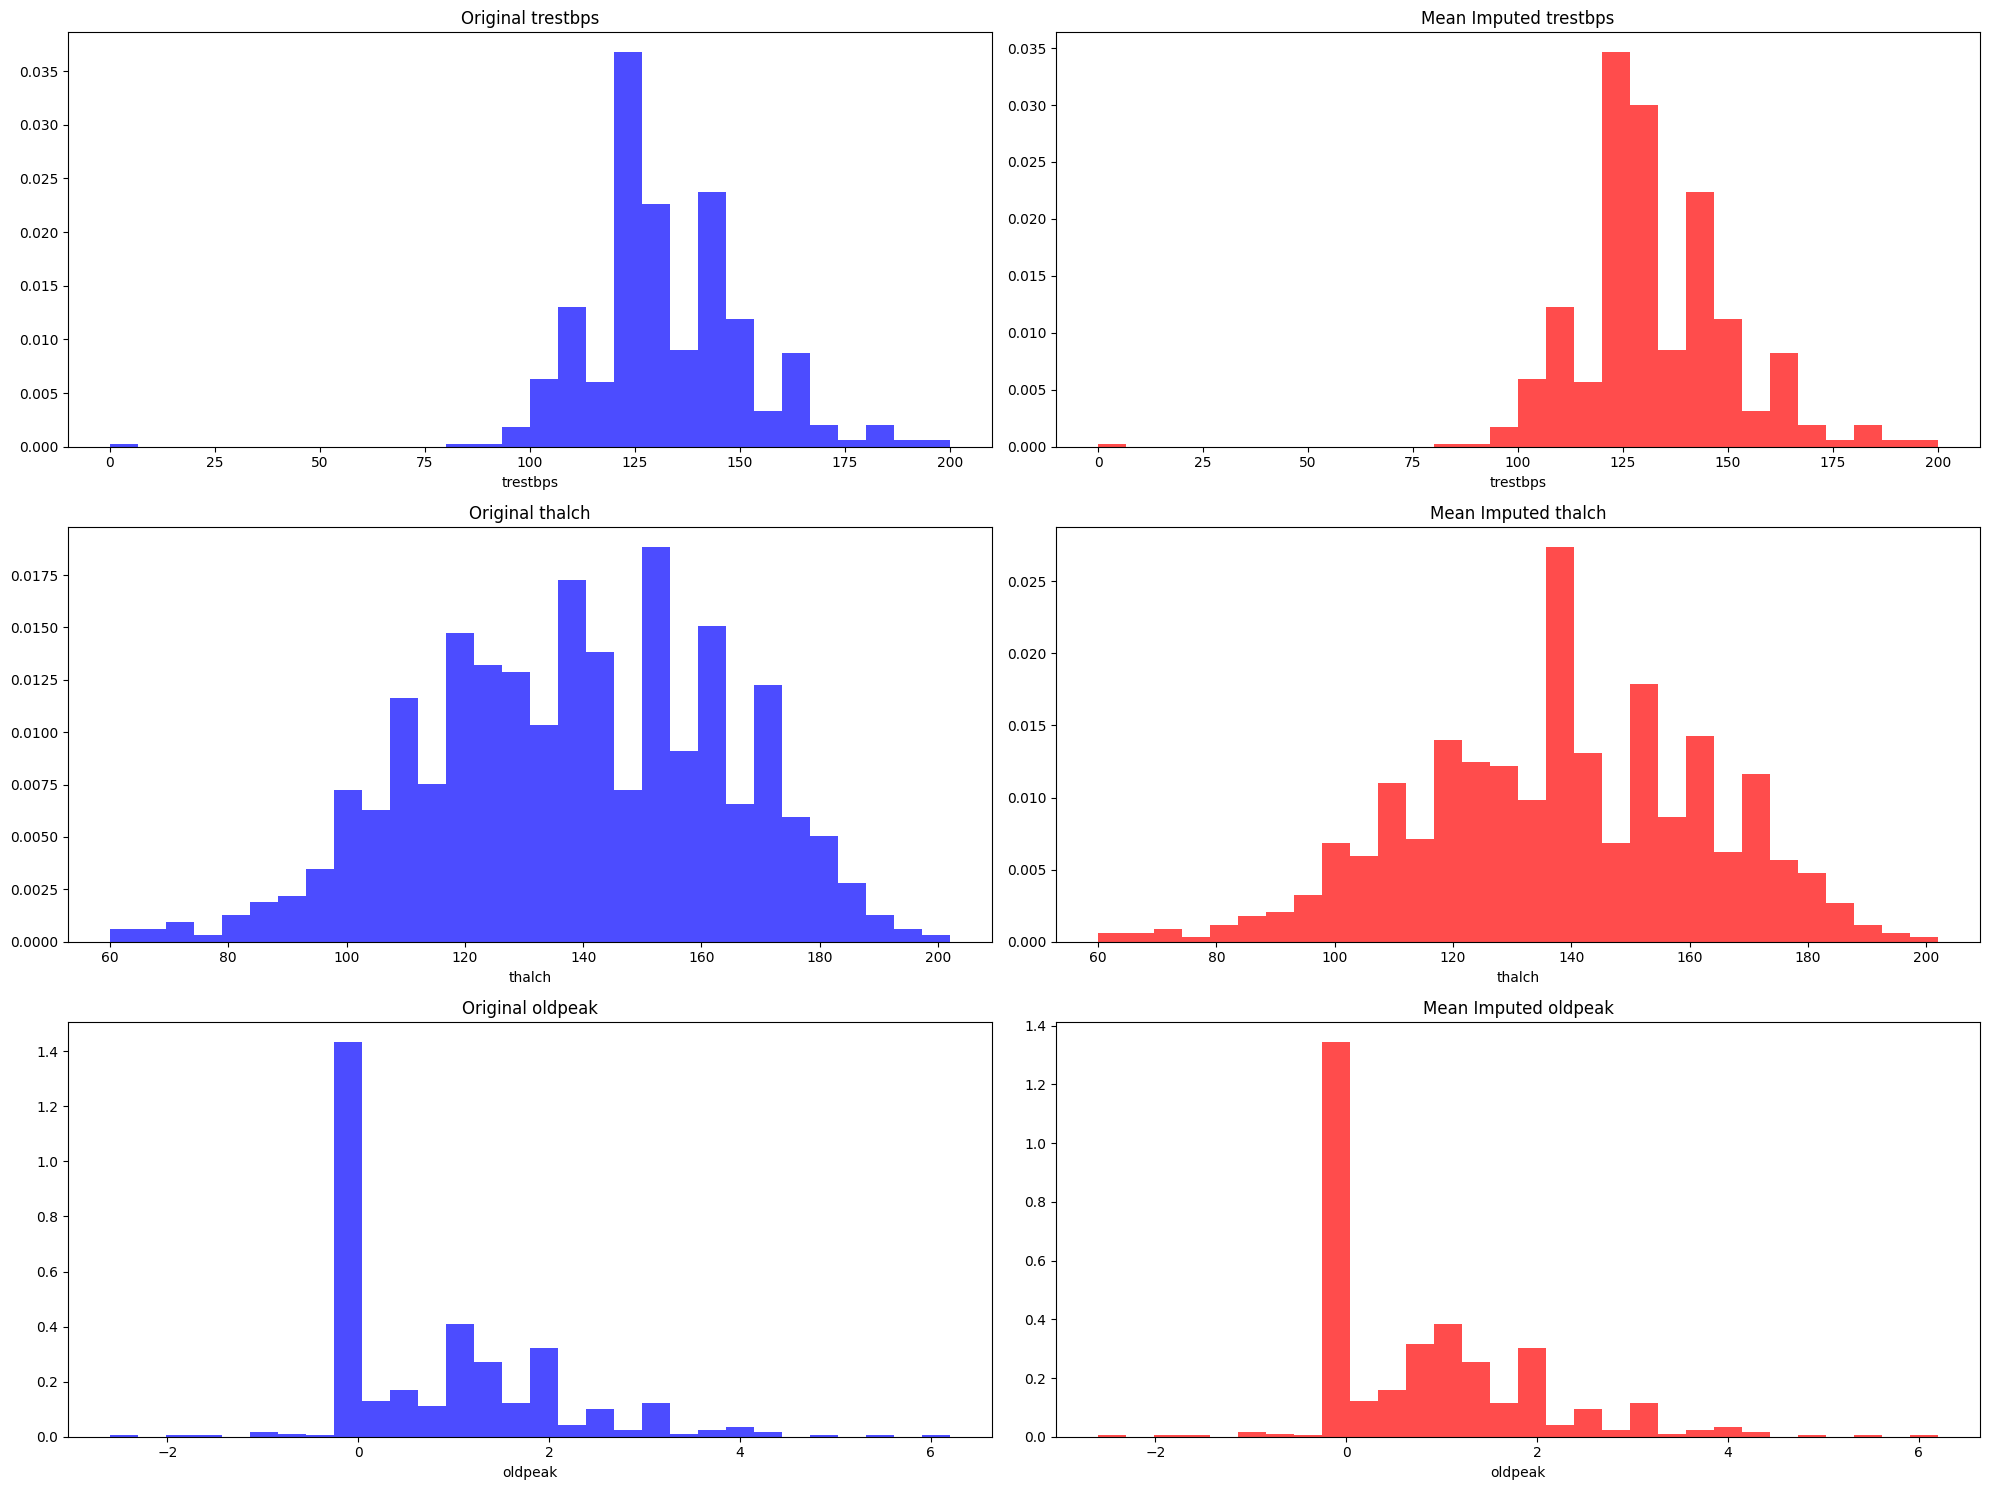

In [20]:
#Create a imputer instance from the SimpleImputer class
mean_imputer  = SimpleImputer(strategy='mean')
X_train_mean = X_train.copy()
X_test_mean = X_test.copy()

X_train_mean[numerical_features] = mean_imputer.fit_transform(X_train[numerical_features])
X_test_mean[numerical_features] = mean_imputer.transform(X_test[numerical_features])


#Find which numerical features had missing values
numerical_missings = []

for col in numerical_features:
  if X_train[col].isnull().sum() > 0:
    numerical_missings.append(col)
print(f"Numerical features with missing values: {numerical_missings}")

if numerical_missings:
  fig, axes = plt.subplots(len(numerical_missings), 2, figsize=(20, 5*len(numerical_missings)))
    
  if len(numerical_missings) == 1:
    axes = axes.reshape(1, -1)
  
  for i,feature in enumerate(numerical_missings):
    axes[i,0].hist(X_train[feature].dropna(), bins=30, alpha=0.7, color='blue', density=True)
    axes[i,0].set_title(f'Original {feature}')
    axes[i,0].set_xlabel(feature)
    
    # Mean imputation
    axes[i,1].hist(X_train_mean[feature], bins=30, alpha=0.7, color='red', density=True)
    axes[i,1].set_title(f'Mean Imputed {feature}')
    axes[i,1].set_xlabel(feature)
  
  plt.tight_layout()
  plt.show()


Now I will perform the median imputation on the numerical features

Numerical features with missing values: ['trestbps', 'thalch', 'oldpeak']


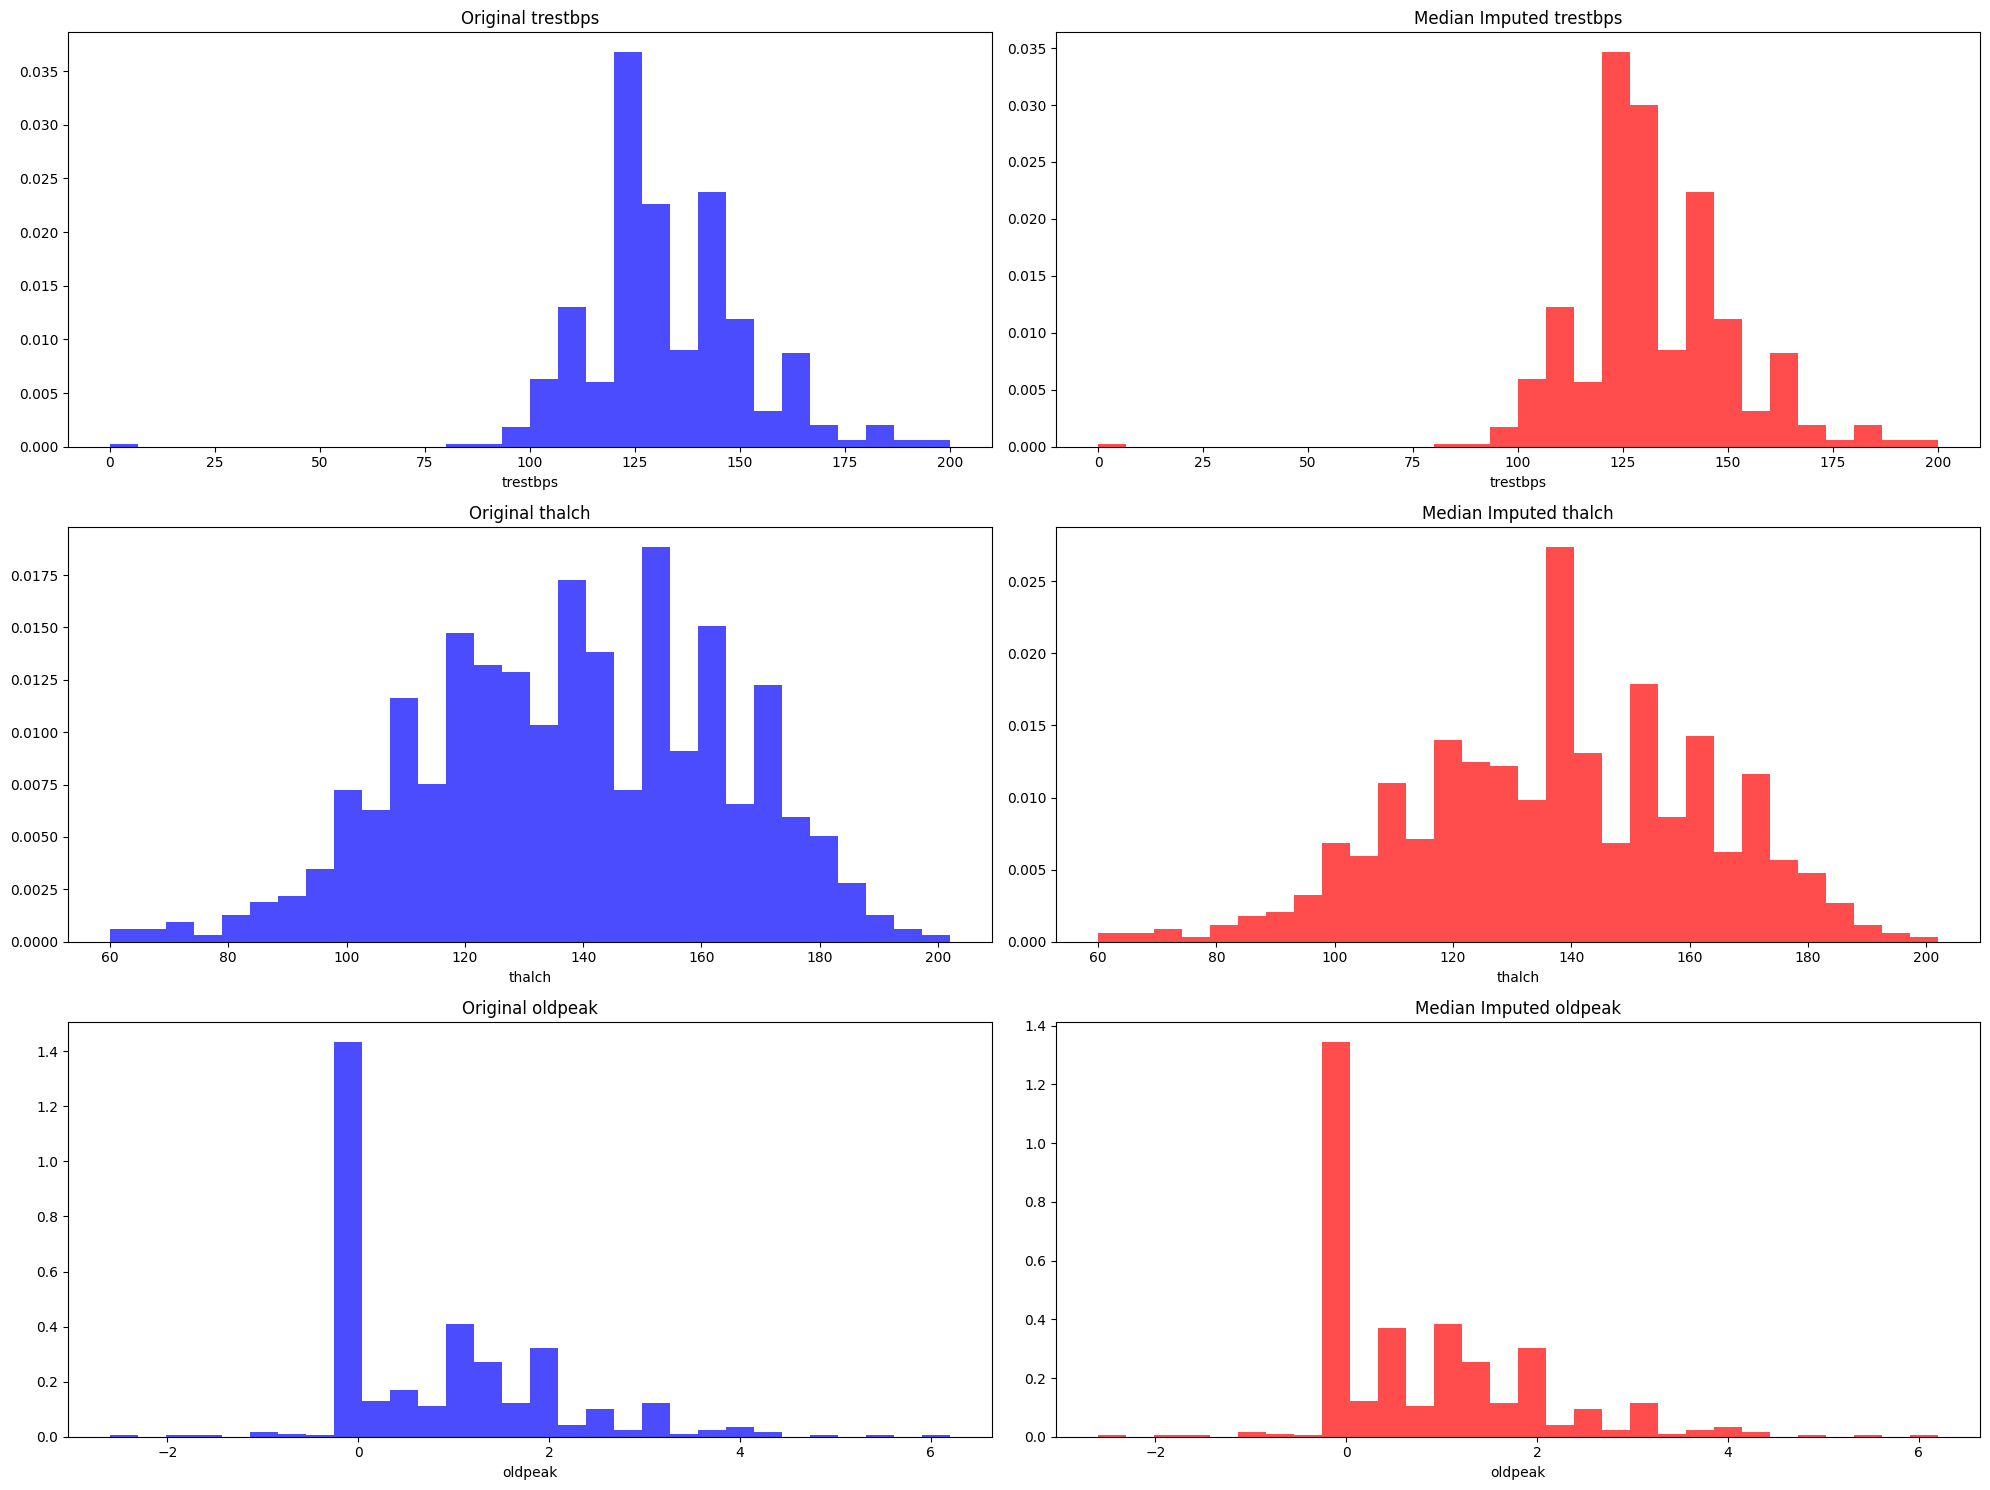

In [21]:
median_imputer  = SimpleImputer(strategy='median')
X_train_median = X_train.copy()
X_test_median = X_test.copy()

X_train_median[numerical_features] = median_imputer.fit_transform(X_train[numerical_features])
X_test_median[numerical_features] = median_imputer.transform(X_test[numerical_features])

#Find which numerical features had missing values
numerical_missings = []

for col in numerical_features:
  if X_train[col].isnull().sum() > 0:
    numerical_missings.append(col)
print(f"Numerical features with missing values: {numerical_missings}")

if numerical_missings:
  fig, axes = plt.subplots(len(numerical_missings), 2, figsize=(20, 5*len(numerical_missings)))
    
  if len(numerical_missings) == 1:
    axes = axes.reshape(1, -1)
  
  for i,feature in enumerate(numerical_missings):
    axes[i,0].hist(X_train[feature].dropna(), bins=30, alpha=0.7, color='blue', density=True)
    axes[i,0].set_title(f'Original {feature}')
    axes[i,0].set_xlabel(feature)
    
    # Mean imputation
    axes[i,1].hist(X_train_median[feature], bins=30, alpha=0.7, color='red', density=True)
    axes[i,1].set_title(f'Median Imputed {feature}')
    axes[i,1].set_xlabel(feature)
  
  plt.tight_layout()
  plt.show()


In [25]:
for feature in numerical_missings:
    print(f"\n{feature.upper()} Statistics:")
    print(f"Original mean: {X_train[feature].mean():.3f}, std: {X_train[feature].std():.3f}")
    print(f"Mean imputation: {X_train_mean[feature].mean():.3f}, std: {X_train_mean[feature].std():.3f}")
    print(f"Median imputation: {X_train_median[feature].mean():.3f}, std: {X_train_median[feature].std():.3f}")
    # print(f"KNN imputation: {X_train_knn[feature].mean():.3f}, std: {X_train_knnfeature].std():.3f}")



TRESTBPS Statistics:
Original mean: 131.771, std: 19.063
Mean imputation: 131.771, std: 18.504
Median imputation: 131.669, std: 18.508

THALCH Statistics:
Original mean: 138.079, std: 25.483
Mean imputation: 138.079, std: 24.810
Median imputation: 138.179, std: 24.813

OLDPEAK Statistics:
Original mean: 0.888, std: 1.104
Mean imputation: 0.888, std: 1.069
Median imputation: 0.864, std: 1.073


Now I will perform mode imputation on the categorical features

In [ ]:
# Handle categorical features if they have missing values
print("=== HANDLING CATEGORICAL MISSING VALUES ===")

# Check if categorical features have missing values
cat_missing = X_train[categorical_features].isnull().sum()
if cat_missing.sum() > 0:
    print("Categorical features with missing values:")
    for col, missing_count in cat_missing[cat_missing > 0].items():
        print(f"{col}: {missing_count} missing values")
    
    # Most frequent (mode) imputation for categorical features
    mode_imputer = SimpleImputer(strategy='most_frequent')
    
    # Apply to all three datasets
    datasets = [
        ('mean', X_train_mean, X_test_mean),
        ('median', X_train_median, X_test_median),
    ]
    
    for name, train_data, test_data in datasets:
        train_data[categorical_features] = mode_imputer.fit_transform(train_data[categorical_features])
        test_data[categorical_features] = mode_imputer.transform(test_data[categorical_features])
    
    print("✅ Categorical imputation completed")
else:
    print("✅ No missing values in categorical features")


=== HANDLING CATEGORICAL MISSING VALUES ===
Categorical features with missing values:
fbs: 79 missing values
exang: 37 missing values
slope: 226 missing values
✅ Categorical imputation completed


Now after imputation I will apply the onehot encoder for encoding the categorical features

In [29]:
#Initialize the OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False,handle_unknown='ignore')

X_train_cat = encoder.fit_transform(X_train_median[categorical_features])
X_test_cat = encoder.transform(X_test_median[categorical_features])

encoded_feature_names = encoder.get_feature_names_out(categorical_features)

X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoded_feature_names, index=X_train_median.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoded_feature_names, index=X_test_median.index)

# Drop original categorical columns and concatenate encoded columns
X_train_final = pd.concat([X_train_median.drop(columns=categorical_features), X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test_median.drop(columns=categorical_features), X_test_cat_df], axis=1)

print("Train shape after encoding:", X_train_final.shape)
print("Test shape after encoding:", X_test_final.shape)
print("Encoded feature columns:", X_train_final.columns.tolist())

# Save preprocessed train and test sets
X_train_final.to_csv('../data/heart_disease_train_preprocessed.csv', index=False)
X_test_final.to_csv('../data/heart_disease_test_preprocessed.csv', index=False)
y_train.to_csv('../data/heart_disease_train_labels.csv', index=False)
y_test.to_csv('../data/heart_disease_test_labels.csv', index=False)

print("✅ Preprocessed data saved successfully!")

Train shape after encoding: (710, 15)
Test shape after encoding: (178, 15)
Encoded feature columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping']
✅ Preprocessed data saved successfully!


In [33]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Load preprocessed data
X_train = pd.read_csv('../data/heart_disease_train_preprocessed.csv')
X_test = pd.read_csv('../data/heart_disease_test_preprocessed.csv')
y_train = pd.read_csv('../data/heart_disease_train_labels.csv').values.ravel()
y_test = pd.read_csv('../data/heart_disease_test_labels.csv').values.ravel()

# Map target variable to 3 classes
def map_to_3_classes(x):
    if x in [0, 2]:
        return 0
    else:  # x in [3, 4,5]
        return 1

y_train_3class = pd.Series(y_train).apply(map_to_3_classes)
y_test_3class = pd.Series(y_test).apply(map_to_3_classes)



# Train MLP and plot loss curve
mlp = MLPClassifier(random_state=42, max_iter=500)
mlp.fit(X_train, y_train_3class)
y_pred_mlp = mlp.predict(X_test)



# Train SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train_3class)
y_pred_svm = svm.predict(X_test)

# Evaluate models
def print_metrics(y_true, y_pred, model_name):
    print(f"\n{model_name} Metrics:")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))

print_metrics(y_test_3class, y_pred_mlp, "MLP")
print_metrics(y_test_3class, y_pred_svm, "SVM")


MLP Metrics:
Accuracy : 0.7303370786516854
Precision: 0.7288728696868811
Recall   : 0.7303370786516854
F1 Score : 0.7287603074119927

SVM Metrics:
Accuracy : 0.6348314606741573
Precision: 0.6300653895745073
Recall   : 0.6348314606741573
F1 Score : 0.6231963998270983


Are there any DUPLICATED rows?

In [29]:
dataset.duplicated().sum()

np.int64(0)

HOW the data looks mathematically??

In [37]:
dataset.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,888.000000,832.000000,888.000000,836.000000,829.000000,888.000000
mean,53.601351,132.100962,199.246622,137.521531,0.891194,1.009009
std,9.376918,19.088858,110.657036,26.014519,1.096021,1.146500
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,1.000000
75%,60.000000,140.000000,268.000000,157.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


Is there any correlation between features?
Correlation means if there is any relation (proportional,inverse or any type of relation between differnt features)

In [ ]:
dataset.corr()

Explanatory Data Analysis(Univariate analysis)

First, we will do the Univariate analysis on categorical data

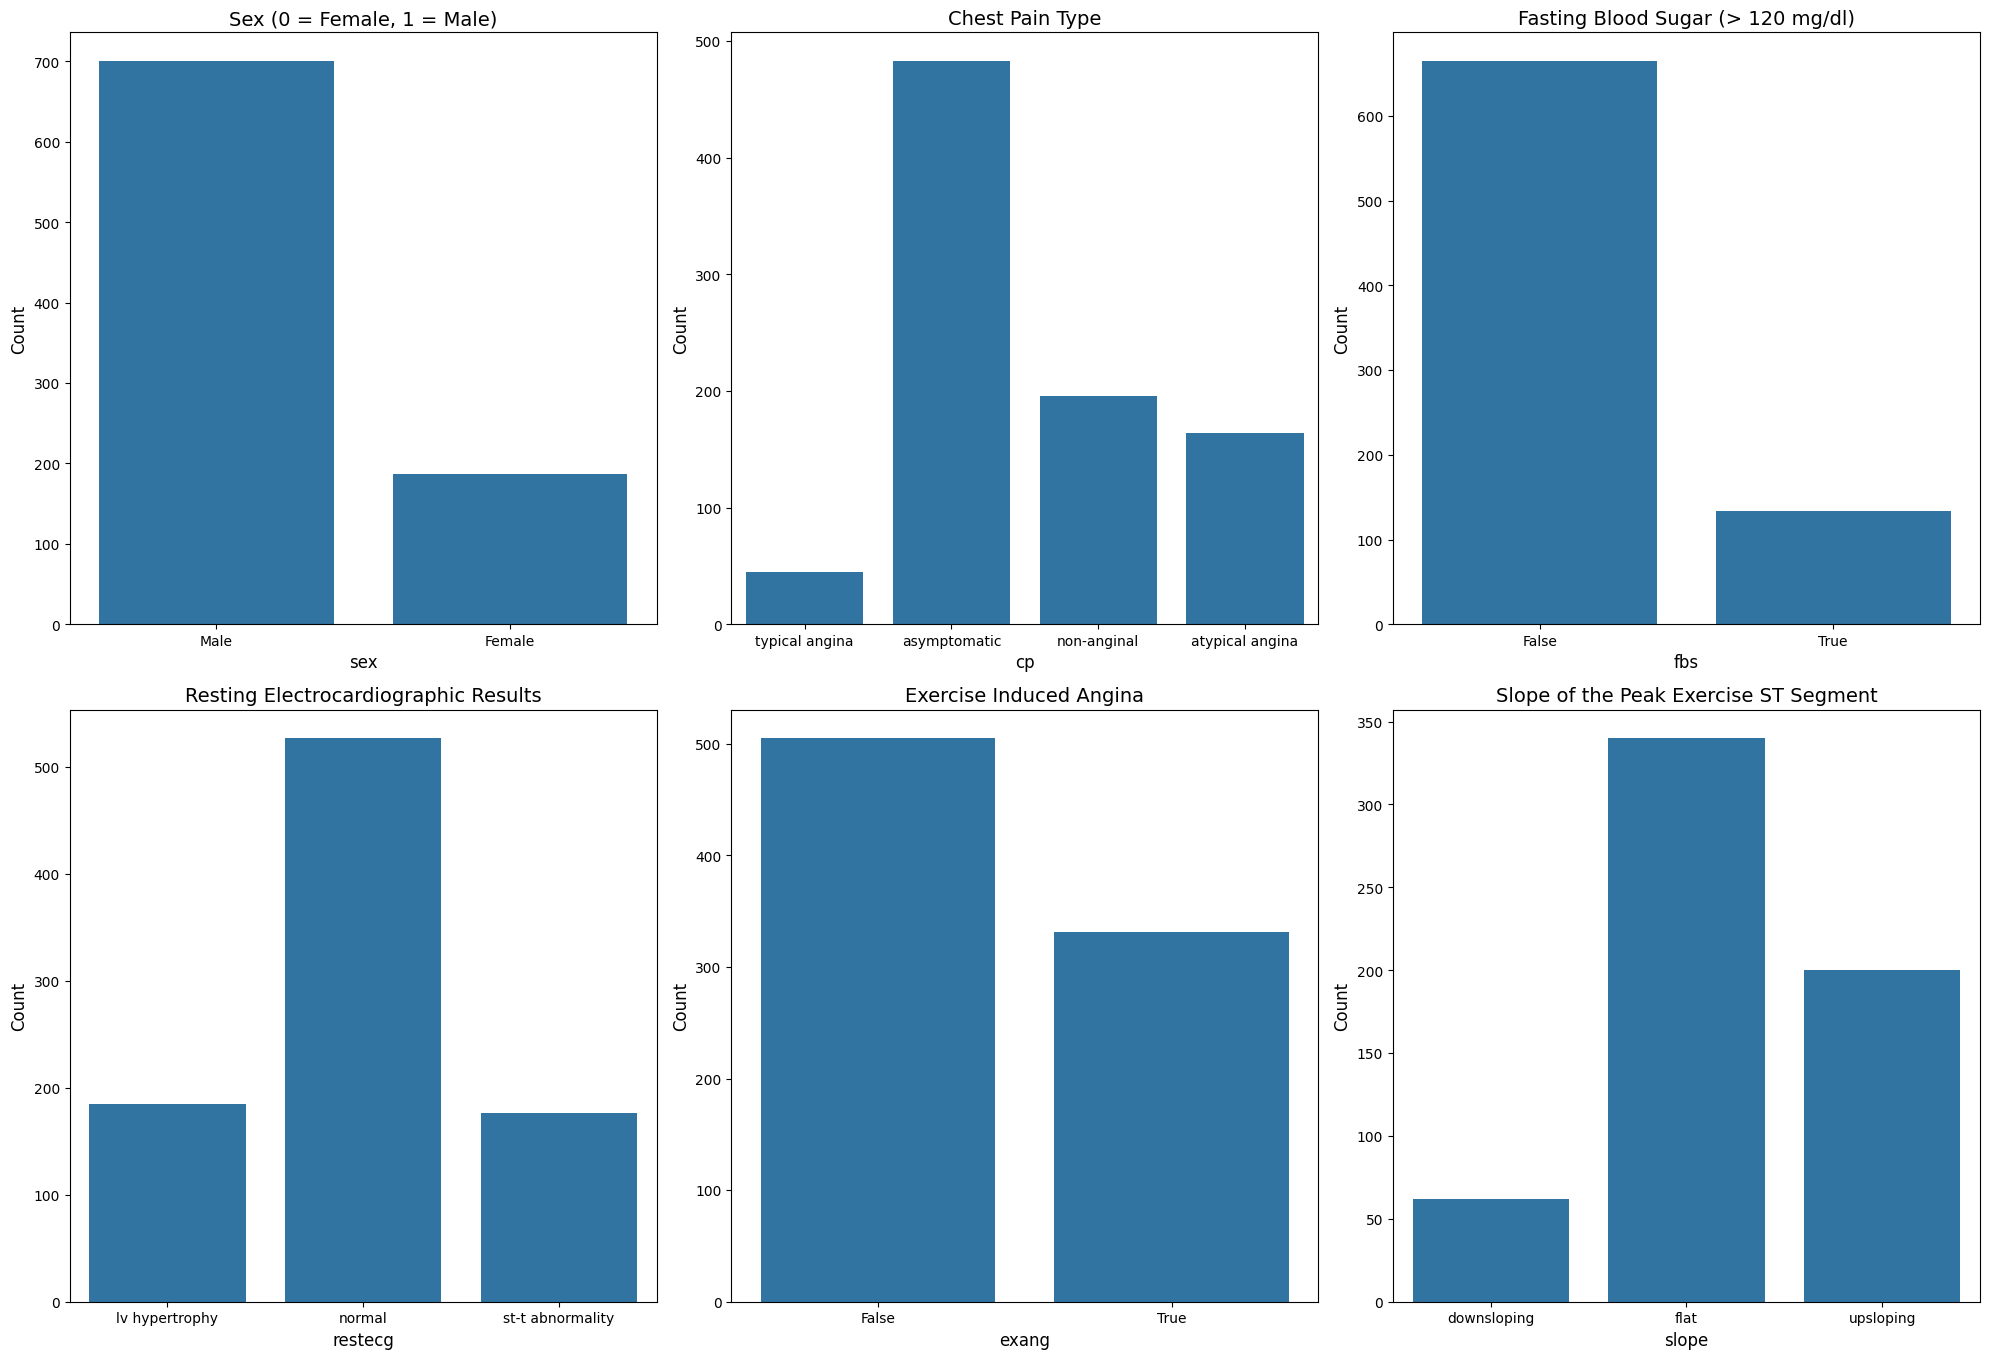

In [38]:

# Using BarChart

import seaborn as sb
import matplotlib.pyplot as plt

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
meaning_of_features = [
    'Sex (0 = Female, 1 = Male)', 
    'Chest Pain Type', 
    'Fasting Blood Sugar (> 120 mg/dl)',
    'Resting Electrocardiographic Results', 
    'Exercise Induced Angina', 
    'Slope of the Peak Exercise ST Segment', 
]

plt.figure(figsize=(20, 20))

# loop through each column and its meaning
for i, (col, meaning) in enumerate(zip(categorical_features, meaning_of_features), 1):
    plt.subplot(3, 3, i)  # (rows, cols, index)
    sb.countplot(data=dataset, x=col)
    
    # use the human-readable meaning as title
    plt.title(f'{meaning}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()


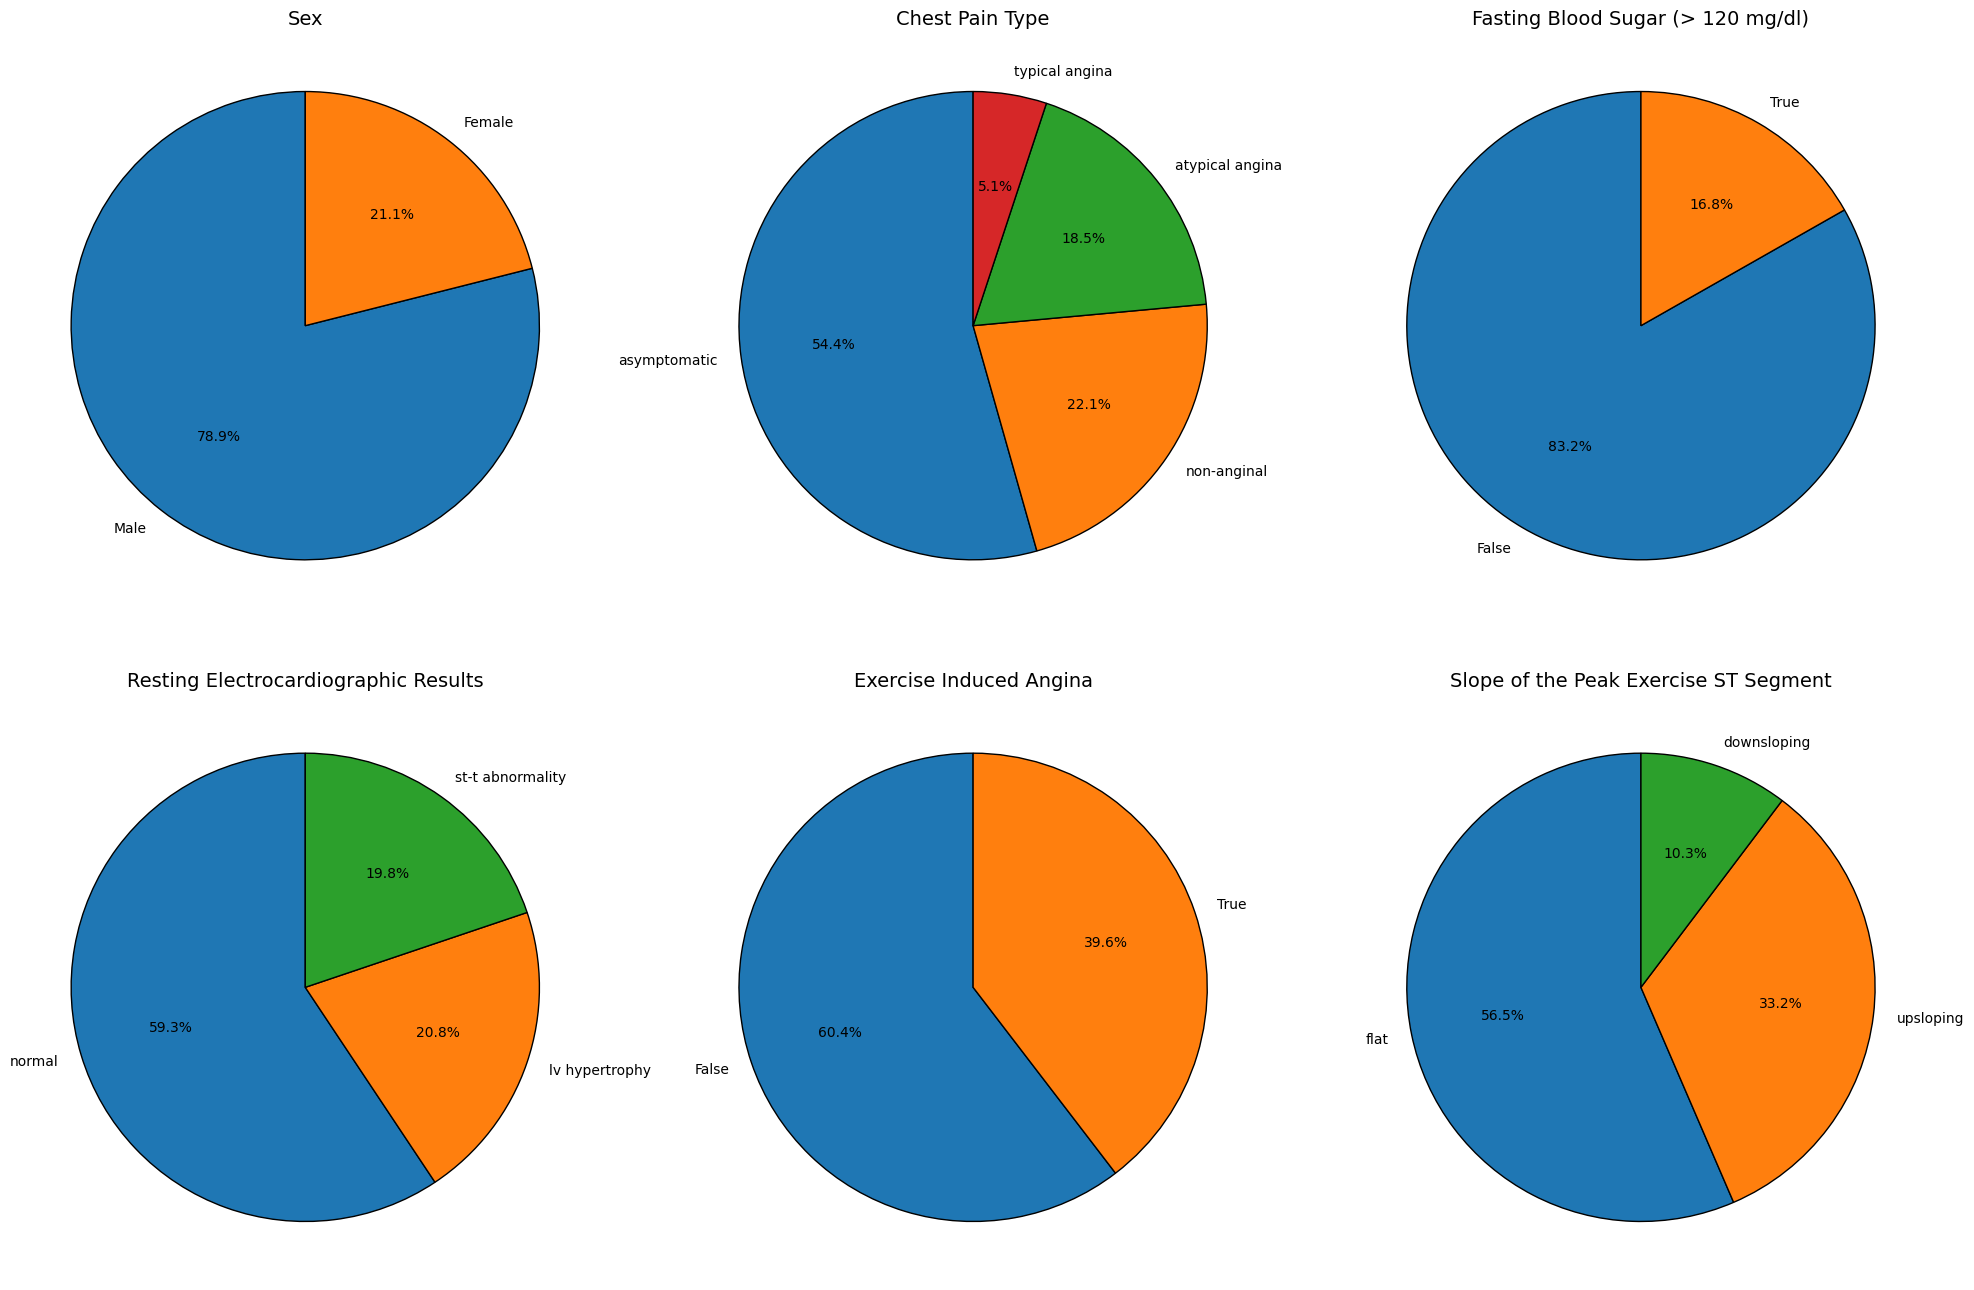

In [40]:
# Using PieChart

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope']
meaning_of_features = [
    'Sex', 
    'Chest Pain Type', 
    'Fasting Blood Sugar (> 120 mg/dl)',
    'Resting Electrocardiographic Results', 
    'Exercise Induced Angina', 
    'Slope of the Peak Exercise ST Segment'
]

plt.figure(figsize=(20, 20))

for i, (col, meaning) in enumerate(zip(categorical_features, meaning_of_features), 1):
    plt.subplot(3, 3, i)
    
    # get value counts
    counts = dataset[col].value_counts()
    
    # make pie chart
    plt.pie(
        counts, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        wedgeprops={'edgecolor': 'black'}
    )
    
    plt.title(f'{meaning}', fontsize=14)

plt.tight_layout()
plt.show()

Then, we will do UNIVARIATE Analysis on NUMERICAL DATA

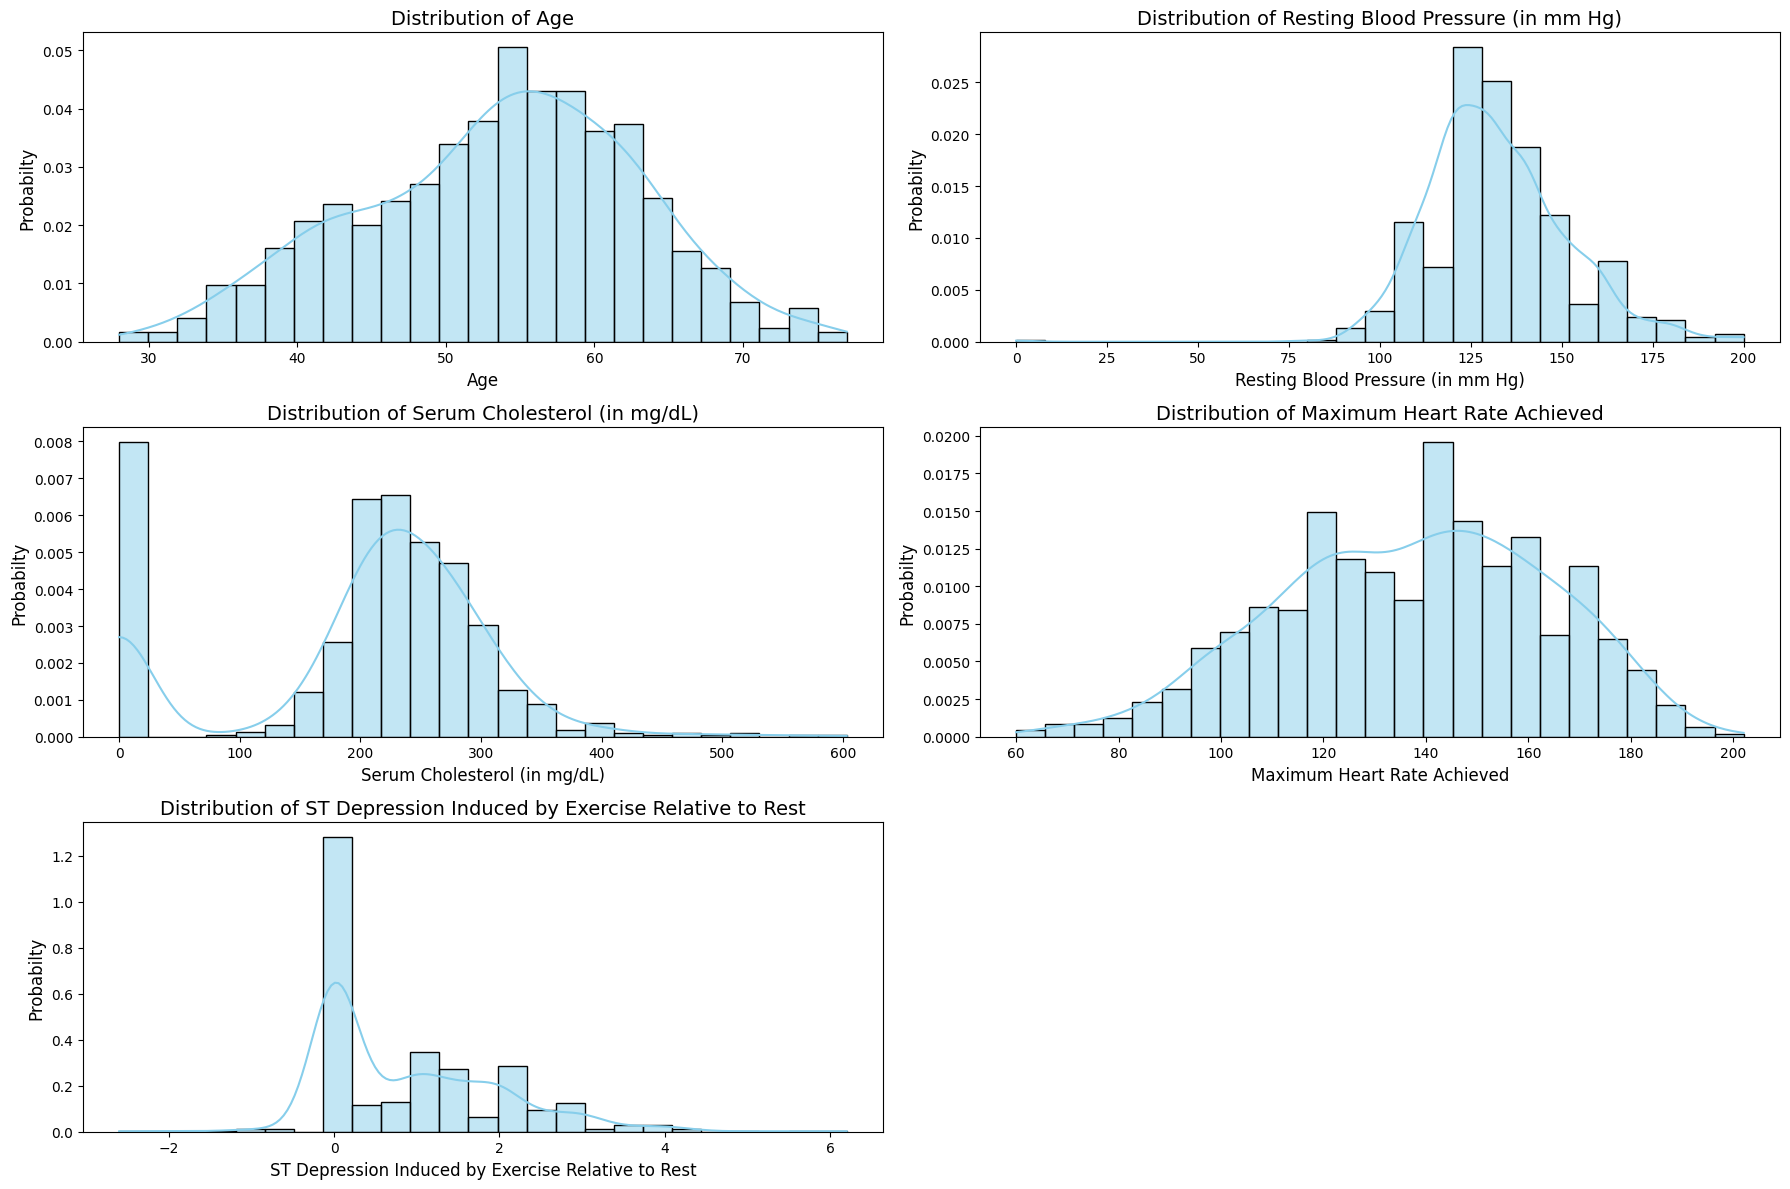

In [41]:
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
meaning_of_numerical_features = [
    'Age',
    'Resting Blood Pressure (in mm Hg)',
    'Serum Cholesterol (in mg/dL)',
    'Maximum Heart Rate Achieved',
    'ST Depression Induced by Exercise Relative to Rest'
]

plt.figure(figsize=(18, 12))

for i, (col, meaning) in enumerate(zip(numerical_features, meaning_of_numerical_features), 1):
    plt.subplot(3, 2, i)
    sb.histplot(data=dataset, x=col, kde=True, stat='density',color='skyblue', bins=25)
    plt.title(f'Distribution of {meaning}', fontsize=14)
    plt.xlabel(meaning, fontsize=12)
    plt.ylabel('Probabilty', fontsize=12)

plt.tight_layout()
plt.show()

Explanatrory Data Analysis (Bi-variate Analysis)

For NUMERICAL-NUMERICAL feature (We use Scatterplot)

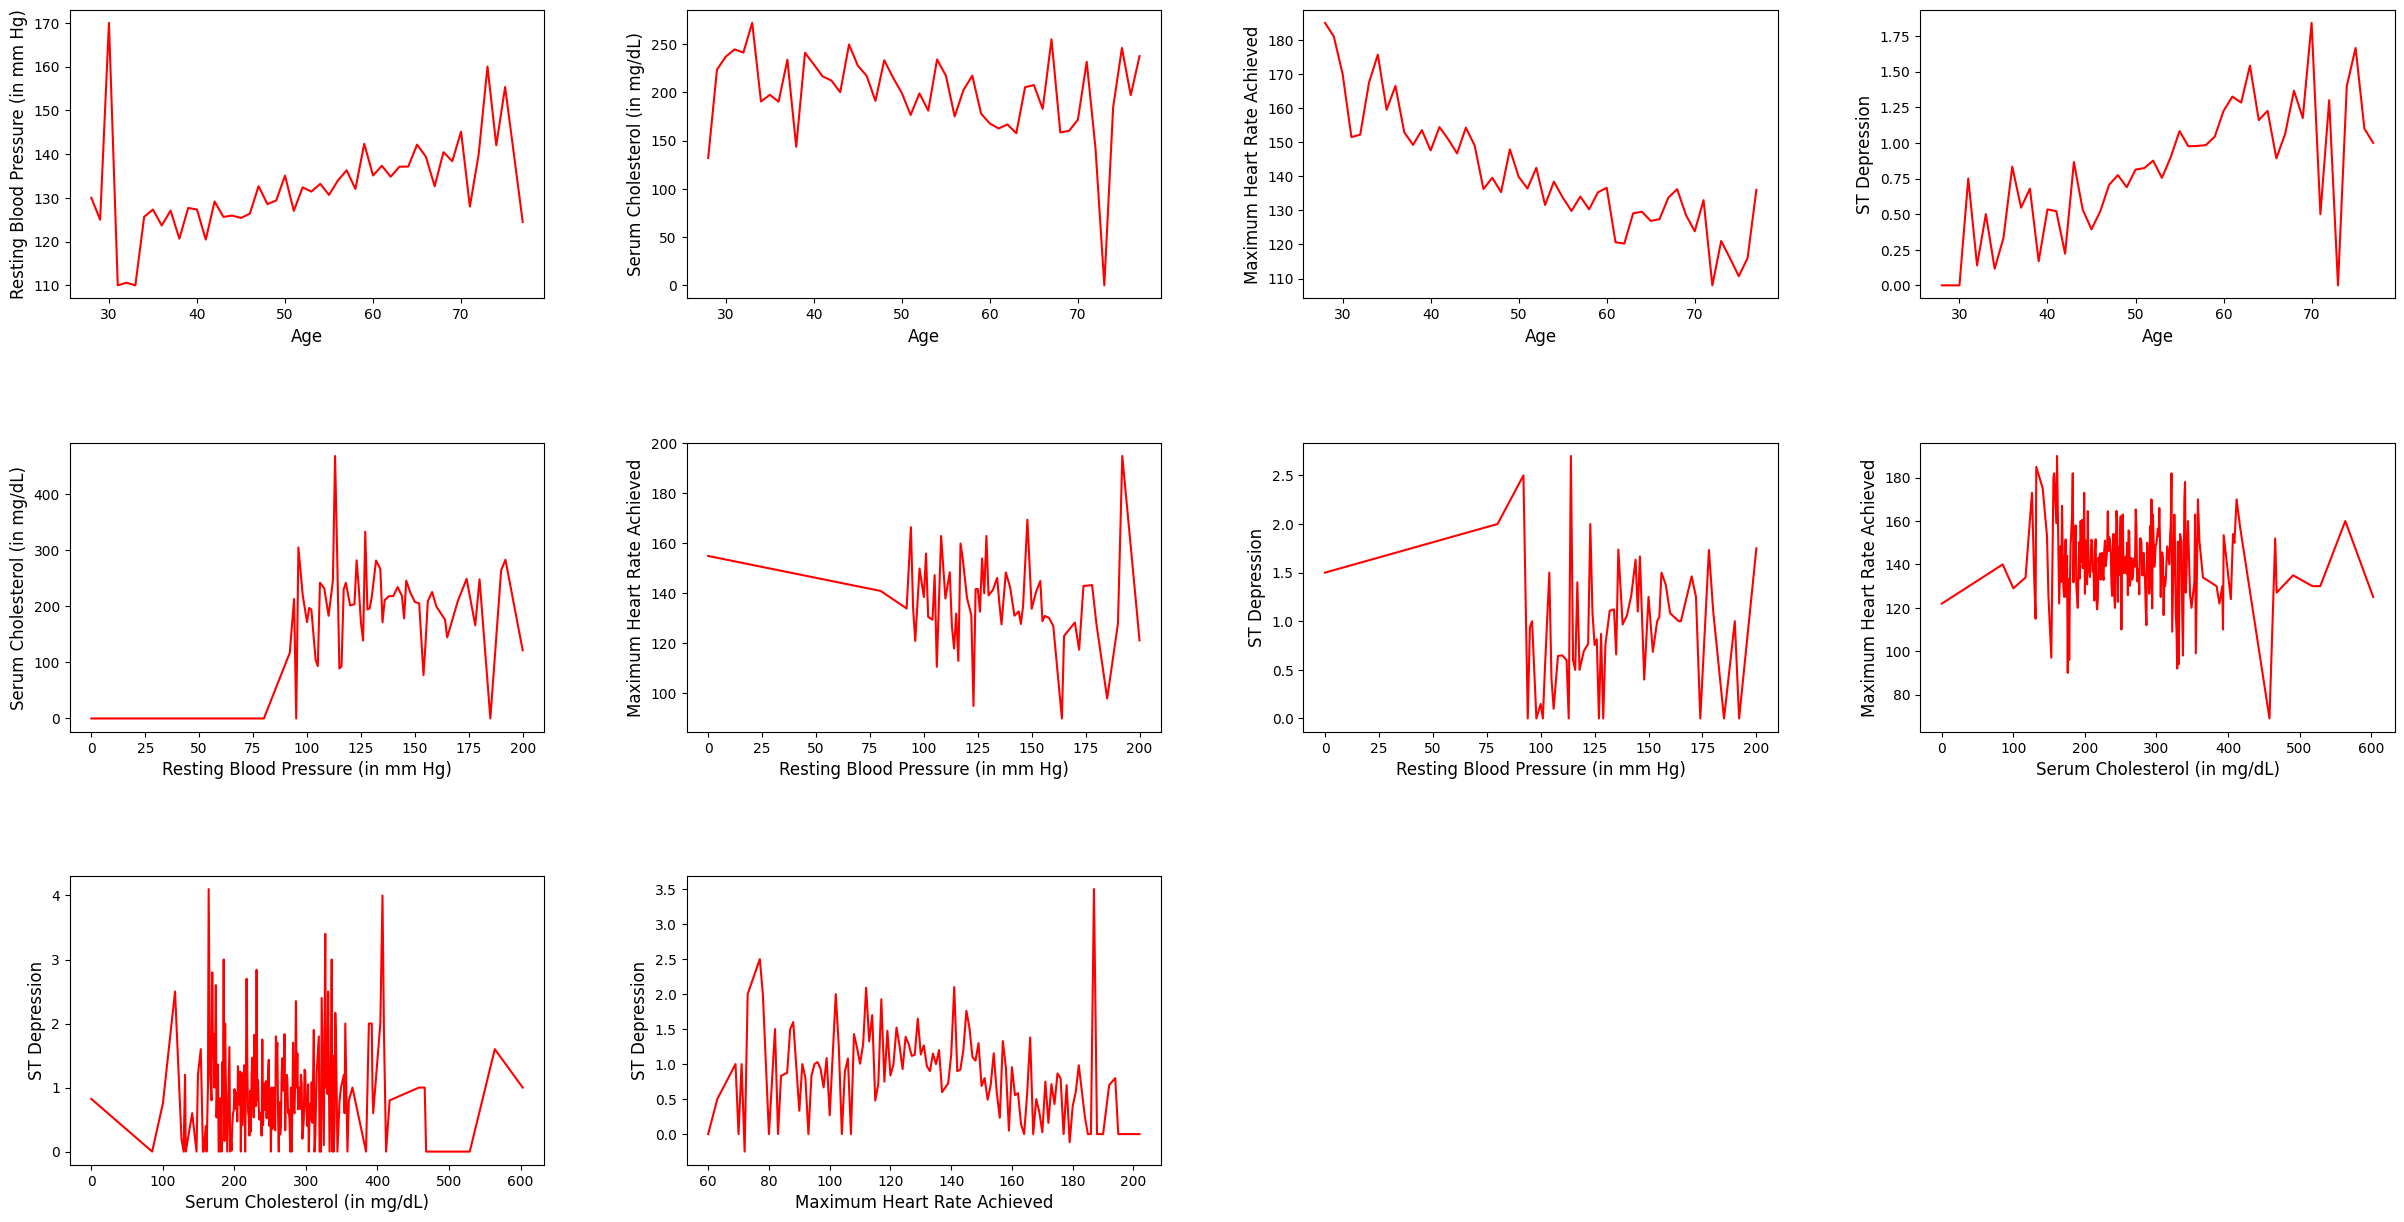

In [42]:

from itertools import combinations

# Numerical features
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
meaning_of_numerical_features = [
    'Age',
    'Resting Blood Pressure (in mm Hg)',
    'Serum Cholesterol (in mg/dL)',
    'Maximum Heart Rate Achieved',
    'ST Depression'
]

# Generate all unique pairs of numerical features
feature_pairs = list(combinations(range(len(numerical_features)), 2))


# Set up figure size
plt.figure(figsize=(30, 15))

# Loop through each pair
for i, (idx1, idx2) in enumerate(feature_pairs, 1):
    col1 = numerical_features[idx1]
    col2 = numerical_features[idx2]
    meaning1 = meaning_of_numerical_features[idx1]
    meaning2 = meaning_of_numerical_features[idx2]
    
    plt.subplot(3, 4, i)  # adjust grid (rows x columns) as needed
    
    # Scatterplot
    sb.lineplot(data=dataset, x=col1, y=col2, color='red',errorbar=None)
    
    # Axis labels
    plt.xlabel(meaning1, fontsize=12)
    plt.ylabel(meaning2, fontsize=12)
    
    

# Adjust spacing between plots
plt.subplots_adjust(wspace=0.3, hspace=0.5)

plt.show()


In [ ]:
# Using PANDAS PROFILING for automating all those plots and analysis
p = ProfileReport(dataset,title="Heart Disease Dataset Profiling Report")
p.to_file("heart_disease_profiling_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 36.47it/s]


# Feature Scaling

Since we observed significant differences in feature ranges (e.g., oldpeak: -2.6 to 6.2, chol: 0-600, thalch: 0-200), and we plan to use MLP and SVM models which are sensitive to feature scales, we need to apply feature scaling.

**Why Feature Scaling is Important for MLP and SVM:**
- **MLP (Neural Networks):** Features with larger scales can dominate the learning process and slow convergence
- **SVM:** The algorithm relies on distance calculations, so features with larger scales will have disproportionate influence
- **Both models** use gradient-based optimization that works better with normalized features

In [ ]:
# Import preprocessing modules
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Let's first examine the exact ranges of our numerical features
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

print("Feature Ranges BEFORE Scaling:")
print("-" * 40)
for feature in numerical_features:
    min_val = dataset[feature].min()
    max_val = dataset[feature].max()
    range_val = max_val - min_val
    print(f"{feature:12}: Min={min_val:6.1f}, Max={max_val:6.1f}, Range={range_val:6.1f}")

## Different Scaling Methods

We'll apply two common scaling methods:

1. **StandardScaler (Z-score normalization):**
   - Transforms features to have mean=0 and std=1
   - Formula: (x - mean) / std
   - Good when features are normally distributed
   - **Recommended for MLP and SVM**

2. **MinMaxScaler:**
   - Scales features to a fixed range [0,1]
   - Formula: (x - min) / (max - min)
   - Good when you want bounded values

In [ ]:
# Apply StandardScaler (Recommended for MLP and SVM)
scaler_standard = StandardScaler()

# Create a copy of the dataset for scaling
dataset_scaled_standard = dataset.copy()

# Apply scaling only to numerical features
dataset_scaled_standard[numerical_features] = scaler_standard.fit_transform(dataset[numerical_features])

print("Feature Statistics AFTER Standard Scaling:")
print("-" * 50)
for feature in numerical_features:
    mean_val = dataset_scaled_standard[feature].mean()
    std_val = dataset_scaled_standard[feature].std()
    min_val = dataset_scaled_standard[feature].min()
    max_val = dataset_scaled_standard[feature].max()
    print(f"{feature:12}: Mean={mean_val:6.3f}, Std={std_val:6.3f}, Min={min_val:6.2f}, Max={max_val:6.2f}")

In [ ]:
# Apply MinMaxScaler (Alternative option)
scaler_minmax = MinMaxScaler()

# Create another copy for MinMax scaling
dataset_scaled_minmax = dataset.copy()

# Apply scaling only to numerical features
dataset_scaled_minmax[numerical_features] = scaler_minmax.fit_transform(dataset[numerical_features])

print("Feature Statistics AFTER MinMax Scaling:")
print("-" * 50)
for feature in numerical_features:
    mean_val = dataset_scaled_minmax[feature].mean()
    std_val = dataset_scaled_minmax[feature].std()
    min_val = dataset_scaled_minmax[feature].min()
    max_val = dataset_scaled_minmax[feature].max()
    print(f"{feature:12}: Mean={mean_val:6.3f}, Std={std_val:6.3f}, Min={min_val:6.2f}, Max={max_val:6.2f}")

In [ ]:
# Visualize the effect of scaling
plt.figure(figsize=(20, 15))

for i, feature in enumerate(numerical_features, 1):
    # Original data
    plt.subplot(5, 3, (i-1)*3 + 1)
    sb.histplot(data=dataset, x=feature, kde=True, color='blue', alpha=0.7)
    plt.title(f'Original {feature}', fontsize=12)
    plt.xlabel(feature)
    
    # Standard scaled
    plt.subplot(5, 3, (i-1)*3 + 2)
    sb.histplot(data=dataset_scaled_standard, x=feature, kde=True, color='red', alpha=0.7)
    plt.title(f'Standard Scaled {feature}', fontsize=12)
    plt.xlabel(feature)
    
    # MinMax scaled
    plt.subplot(5, 3, (i-1)*3 + 3)
    sb.histplot(data=dataset_scaled_minmax, x=feature, kde=True, color='green', alpha=0.7)
    plt.title(f'MinMax Scaled {feature}', fontsize=12)
    plt.xlabel(feature)

plt.tight_layout()
plt.show()

## Recommendation for MLP and SVM

**For your MLP and SVM models, I recommend using the StandardScaler** because:

1. **StandardScaler is generally preferred** for neural networks (MLP) and SVM
2. **Preserves the shape** of the original distribution
3. **Handles outliers better** than MinMaxScaler
4. **Works well with gradient-based optimization** algorithms used in both MLP and SVM
5. **Most research and implementations** use StandardScaler for these algorithms

**Use the `dataset_scaled_standard` for your MLP and SVM models.**

### Important Notes for Model Training:
- **Always fit the scaler on training data only** and then transform both train and test sets
- **Save the scaler object** to transform new data during prediction
- **Apply the same scaling** to any new data you want to predict on

In [ ]:
# Example of proper scaling workflow for model training
from sklearn.model_selection import train_test_split

# Assuming 'target' is your target variable (you'll need to specify the correct column name)
# For demonstration, I'll assume there's a target column - replace with your actual target column
print("Available columns in dataset:")
print(dataset.columns.tolist())
print("\n** When you do train-test split for modeling, follow this pattern: **")

# Example workflow (commented out since we don't know the target column yet)
"""
# Separate features and target
X = dataset[numerical_features + categorical_features]  # All features
y = dataset['target_column_name']  # Replace with actual target column

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize scaler
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train[numerical_features])
X_test_scaled = scaler.transform(X_test[numerical_features])  # Only transform, don't fit!

# Create scaled dataframes
X_train_final = X_train.copy()
X_test_final = X_test.copy()
X_train_final[numerical_features] = X_train_scaled
X_test_final[numerical_features] = X_test_scaled

# Now use X_train_final and X_test_final for your MLP and SVM models
"""